In [1]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving IMDB Dataset.csv to IMDB Dataset.csv
User uploaded file "IMDB Dataset.csv" with length 66212309 bytes


In [2]:
# STEP 1: Install required libraries
!pip install -q xgboost
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)

# Optional: Apply stemming
stemmer = PorterStemmer()

def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

df['cleaned_review'] = df['cleaned_review'].apply(stem_text)

# Encode sentiment labels (positive -> 1, negative -> 0)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

# Train-test split
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!")

✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!


In [6]:
# Install XGBoost (if not already installed)
!pip install xgboost

# Import the classifier
from xgboost import XGBClassifier


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Initialize and train XGBoost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_tfidf)
y_probs_xgb = xgb_model.predict_proba(X_test_tfidf)[:, 1]

print("✅ Clean: XGBoost model trained and predictions made.")


✅ Clean: XGBoost model trained and predictions made.


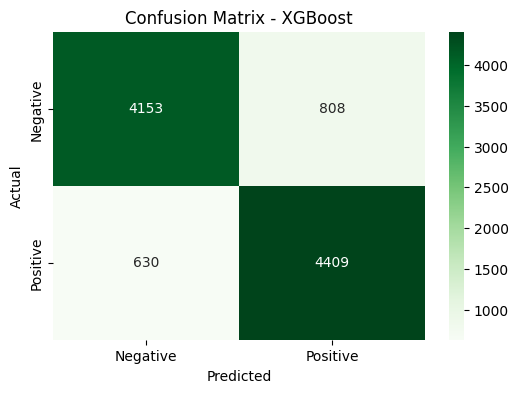

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


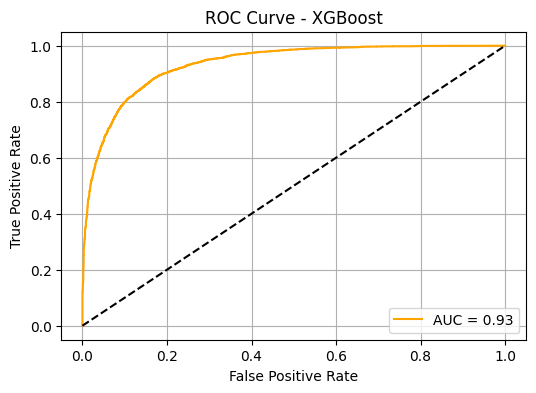

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_probs_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


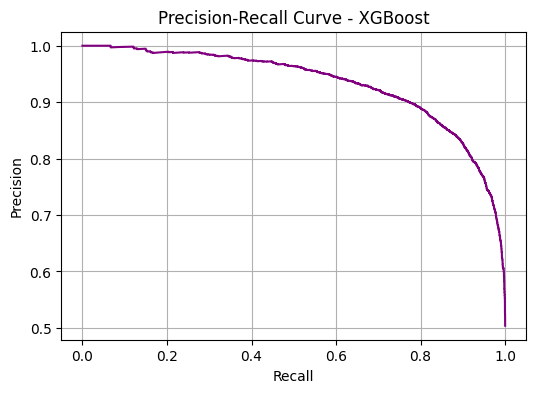

In [12]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs_xgb)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, color='purple')
plt.title("Precision-Recall Curve - XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


<Figure size 1000x600 with 0 Axes>

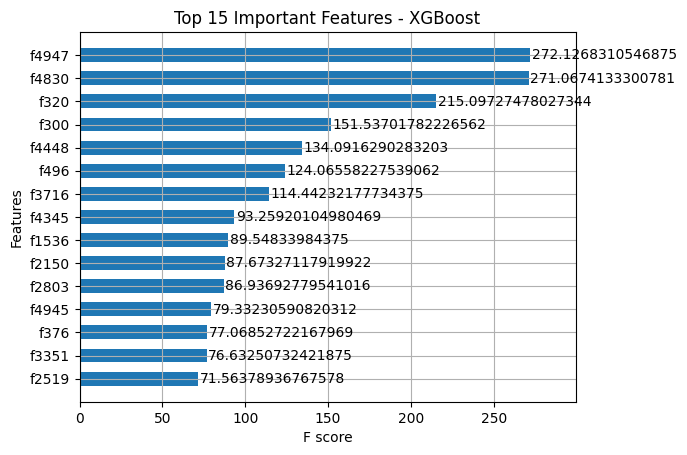

In [13]:
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(xgb_model, max_num_features=15, height=0.6, importance_type='gain')
plt.title("Top 15 Important Features - XGBoost")
plt.show()


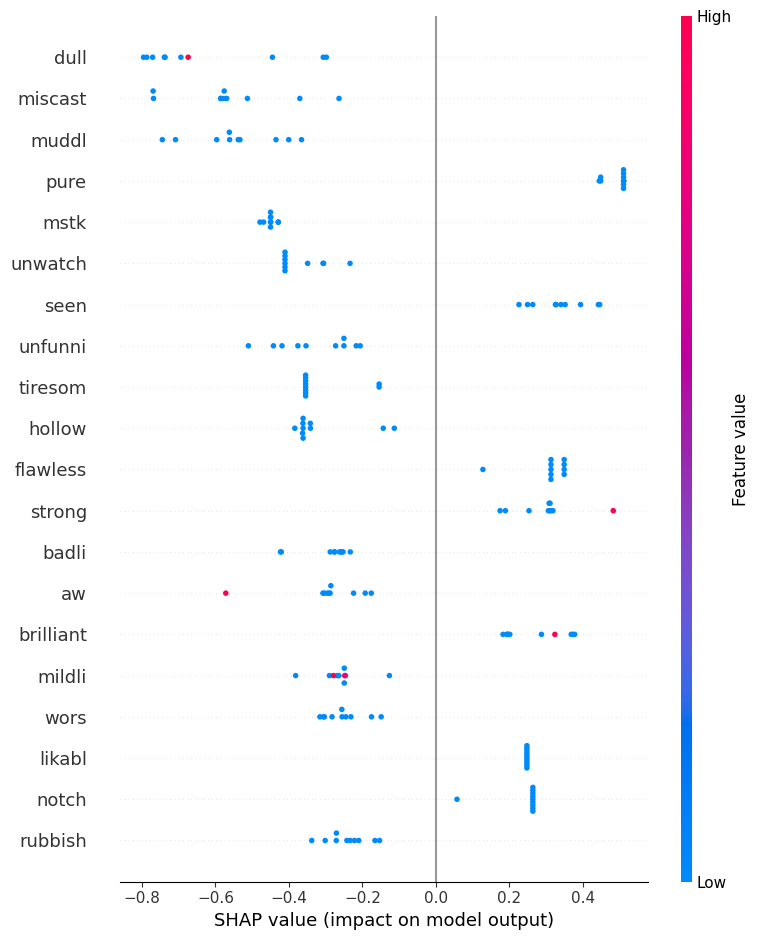

In [15]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_tfidf[:10].toarray())  # small batch for speed

# Replace 'tfidf' with 'vectorizer' to get feature names
shap.summary_plot(shap_values, feature_names=vectorizer.get_feature_names_out())

<ipython-input-16-7397aa49b146>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='True Label', y='Predicted Prob', data=df_probs, palette='pastel')


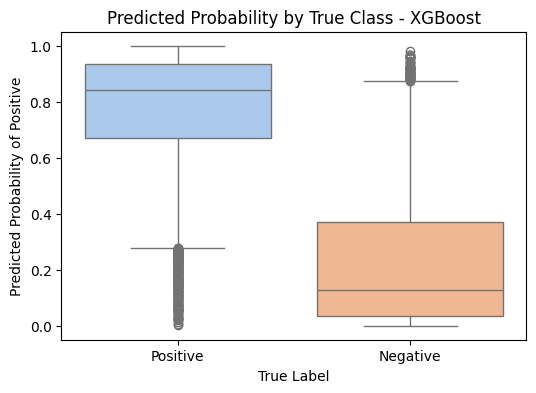

In [16]:
import pandas as pd

df_probs = pd.DataFrame({'True Label': y_test, 'Predicted Prob': y_probs_xgb})
df_probs['True Label'] = df_probs['True Label'].map({0: 'Negative', 1: 'Positive'})

plt.figure(figsize=(6,4))
sns.boxplot(x='True Label', y='Predicted Prob', data=df_probs, palette='pastel')
plt.title("Predicted Probability by True Class - XGBoost")
plt.ylabel("Predicted Probability of Positive")
plt.show()


In [17]:
from sklearn.metrics import classification_report

# Generate the report
print("📋 Classification Report - XGBoost:\n")
print(classification_report(y_test, y_pred_xgb, target_names=['Negative', 'Positive']))


📋 Classification Report - XGBoost:

              precision    recall  f1-score   support

    Negative       0.87      0.84      0.85      4961
    Positive       0.85      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



<ipython-input-18-6f5ae52ec974>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='crest')


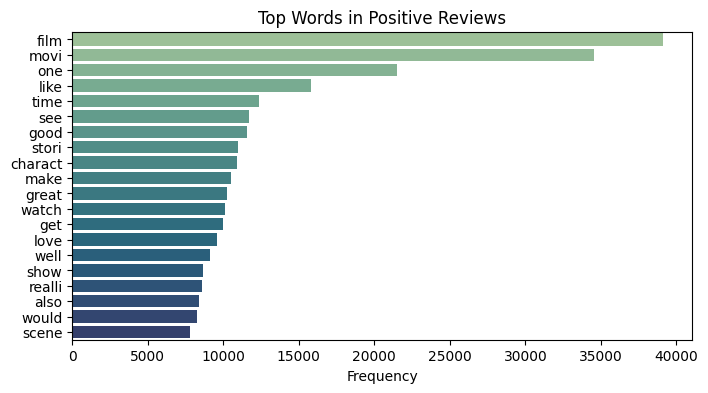

<ipython-input-18-6f5ae52ec974>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='crest')


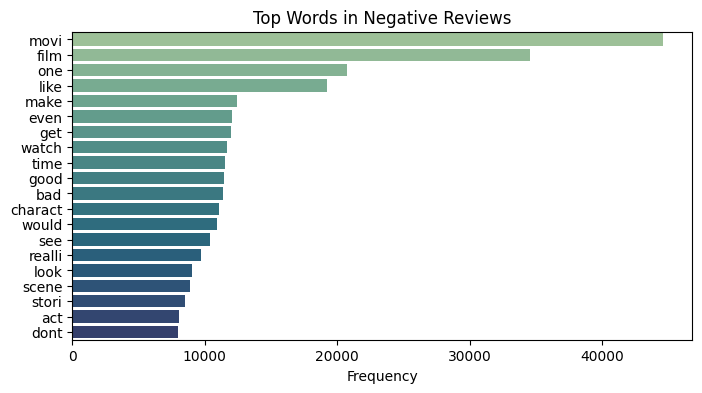

In [18]:
# Add sentiment labels back to raw data
df_train = pd.DataFrame({'review': X_train, 'sentiment': y_train})

# Join all positive and negative reviews
pos_text = " ".join(df_train[df_train['sentiment'] == 1]['review'])
neg_text = " ".join(df_train[df_train['sentiment'] == 0]['review'])

from collections import Counter
import numpy as np

def plot_top_words(text, label):
    words = text.lower().split()
    top = Counter(words).most_common(20)
    words, freqs = zip(*top)
    plt.figure(figsize=(8,4))
    sns.barplot(x=list(freqs), y=list(words), palette='crest')
    plt.title(f"Top Words in {label} Reviews")
    plt.xlabel("Frequency")
    plt.show()

plot_top_words(pos_text, "Positive")
plot_top_words(neg_text, "Negative")


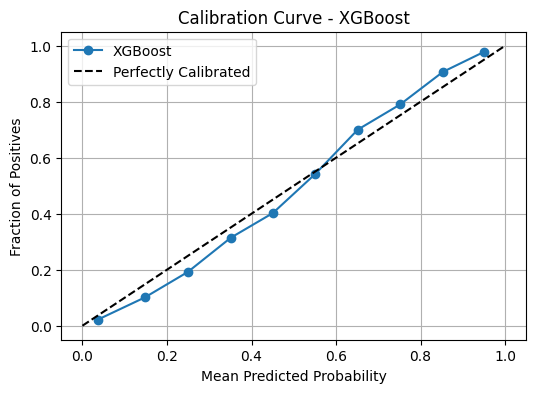

In [22]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_probs_xgb, n_bins=10)

plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0,1], [0,1], 'k--', label='Perfectly Calibrated')
plt.title("Calibration Curve - XGBoost")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.grid(True)
plt.show()
